Importing

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score , recall_score , precision_score , f1_score , confusion_matrix

Reading Data

In [9]:
df = pd.read_csv('final_dataset.csv')
df.head(10)   

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Profit,Month,year,Sales_per_Order,repeat_customer,Active_Customer,Active,First Purchase,First Purchase Month,new_customer
0,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,asasa,Consumer,United States,Henderson,...,219.5820,2020-11,2020,243.9800,1,0,False,2019-10-15,2019-10,0
1,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6.8714,2020-06,2020,7.3100,1,1,True,2020-06-12,2020-06,1
2,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,-383.0310,2019-10,2019,191.5155,1,1,True,2019-10-11,2019-10,1
3,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2.5164,2019-10,2019,11.1840,1,1,True,2019-10-11,2019-10,1
4,6,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,14.1694,2018-06,2018,6.9800,1,1,True,2018-06-09,2018-06,1
5,7,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,1.9656,2018-06,2018,1.8200,1,1,True,2018-06-09,2018-06,1
6,8,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90.7152,2018-06,2018,151.1920,1,1,True,2018-06-09,2018-06,1
7,9,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,5.7825,2018-06,2018,6.1680,1,1,True,2018-06-09,2018-06,1
8,10,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,dsdsdsds,Consumer,United States,Los Angeles,...,34.4700,2018-06,2018,22.9800,1,1,True,2018-06-09,2018-06,1
9,11,CA-2018-115812,2018-06-09,2018-06-14,Standard Class,BH-11710,ssd,Consumer,United States,Los Angeles,...,85.3092,2018-06,2018,189.5760,1,1,True,2018-06-09,2018-06,1


Checking For Nan Values

In [10]:
df.isnull().sum()

Row ID                  0
Order ID                0
Order Date              0
Ship Date               0
Ship Mode               0
Customer ID             0
Customer Name           0
Segment                 0
Country/Region          0
City                    0
State                   0
Postal Code             0
Region                  0
Product ID              0
Category                0
Sub-Category            0
Product Name            0
Sales                   0
Quantity                0
Discount                0
Profit                  0
Month                   0
year                    0
Sales_per_Order         0
repeat_customer         0
Active_Customer         0
Active                  0
First Purchase          0
First Purchase Month    0
new_customer            0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                9993 non-null   int64  
 1   Order ID              9993 non-null   str    
 2   Order Date            9993 non-null   str    
 3   Ship Date             9993 non-null   str    
 4   Ship Mode             9993 non-null   str    
 5   Customer ID           9993 non-null   str    
 6   Customer Name         9993 non-null   str    
 7   Segment               9993 non-null   str    
 8   Country/Region        9993 non-null   str    
 9   City                  9993 non-null   str    
 10  State                 9993 non-null   str    
 11  Postal Code           9993 non-null   int64  
 12  Region                9993 non-null   str    
 13  Product ID            9993 non-null   str    
 14  Category              9993 non-null   str    
 15  Sub-Category          9993 non-n

In [12]:
df.shape

(9993, 30)

In [13]:
df.nunique()

Row ID                  9993
Order ID                5009
Order Date              1236
Ship Date               1334
Ship Mode                  4
Customer ID              793
Customer Name            797
Segment                    3
Country/Region             1
City                     531
State                     49
Postal Code              631
Region                     4
Product ID              1862
Category                   3
Sub-Category              17
Product Name            1849
Sales                   5825
Quantity                  14
Discount                  12
Profit                  7286
Month                     48
year                       4
Sales_per_Order         2938
repeat_customer            2
Active_Customer            2
Active                     2
First Purchase           446
First Purchase Month      42
new_customer               2
dtype: int64

Deleting Columns Not Affecting The Predictions


In [14]:
del_cols = df[['Row ID', 'Order ID', 'Customer ID','Order Date', 'Ship Date', 'Ship Mode','Customer Name',"Product ID",'Product Name','First Purchase','First Purchase Month']]

df.drop(del_cols, axis = 1, inplace = True)

In [15]:
df.head(10)

,Segment,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Month,year,Sales_per_Order,repeat_customer,Active_Customer,Active,new_customer
0,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2020-11,2020,243.9800,1,0,False,0
1,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2020-06,2020,7.3100,1,1,True,1
2,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2019-10,2019,191.5155,1,1,True,1
3,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2019-10,2019,11.1840,1,1,True,1
4,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694,2018-06,2018,6.9800,1,1,True,1
5,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656,2018-06,2018,1.8200,1,1,True,1
6,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152,2018-06,2018,151.1920,1,1,True,1
7,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825,2018-06,2018,6.1680,1,1,True,1
8,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700,2018-06,2018,22.9800,1,1,True,1
9,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092,2018-06,2018,189.5760,1,1,True,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Segment          9993 non-null   str    
 1   Country/Region   9993 non-null   str    
 2   City             9993 non-null   str    
 3   State            9993 non-null   str    
 4   Postal Code      9993 non-null   int64  
 5   Region           9993 non-null   str    
 6   Category         9993 non-null   str    
 7   Sub-Category     9993 non-null   str    
 8   Sales            9993 non-null   float64
 9   Quantity         9993 non-null   int64  
 10  Discount         9993 non-null   float64
 11  Profit           9993 non-null   float64
 12  Month            9993 non-null   str    
 13  year             9993 non-null   int64  
 14  Sales_per_Order  9993 non-null   float64
 15  repeat_customer  9993 non-null   int64  
 16  Active_Customer  9993 non-null   int64  
 17  Active           9993 non

In [17]:
df.nunique()

Segment               3
Country/Region        1
City                531
State                49
Postal Code         631
Region                4
Category              3
Sub-Category         17
Sales              5825
Quantity             14
Discount             12
Profit             7286
Month                48
year                  4
Sales_per_Order    2938
repeat_customer       2
Active_Customer       2
Active                2
new_customer          2
dtype: int64

Simple Histogram For the DataSet

array([[<Axes: title={'center': 'Postal Code'}>,
        <Axes: title={'center': 'Sales'}>,
        <Axes: title={'center': 'Quantity'}>],
       [<Axes: title={'center': 'Discount'}>,
        <Axes: title={'center': 'Profit'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'Sales_per_Order'}>,
        <Axes: title={'center': 'repeat_customer'}>,
        <Axes: title={'center': 'Active_Customer'}>],
       [<Axes: title={'center': 'new_customer'}>, <Axes: >, <Axes: >]],
      dtype=object)

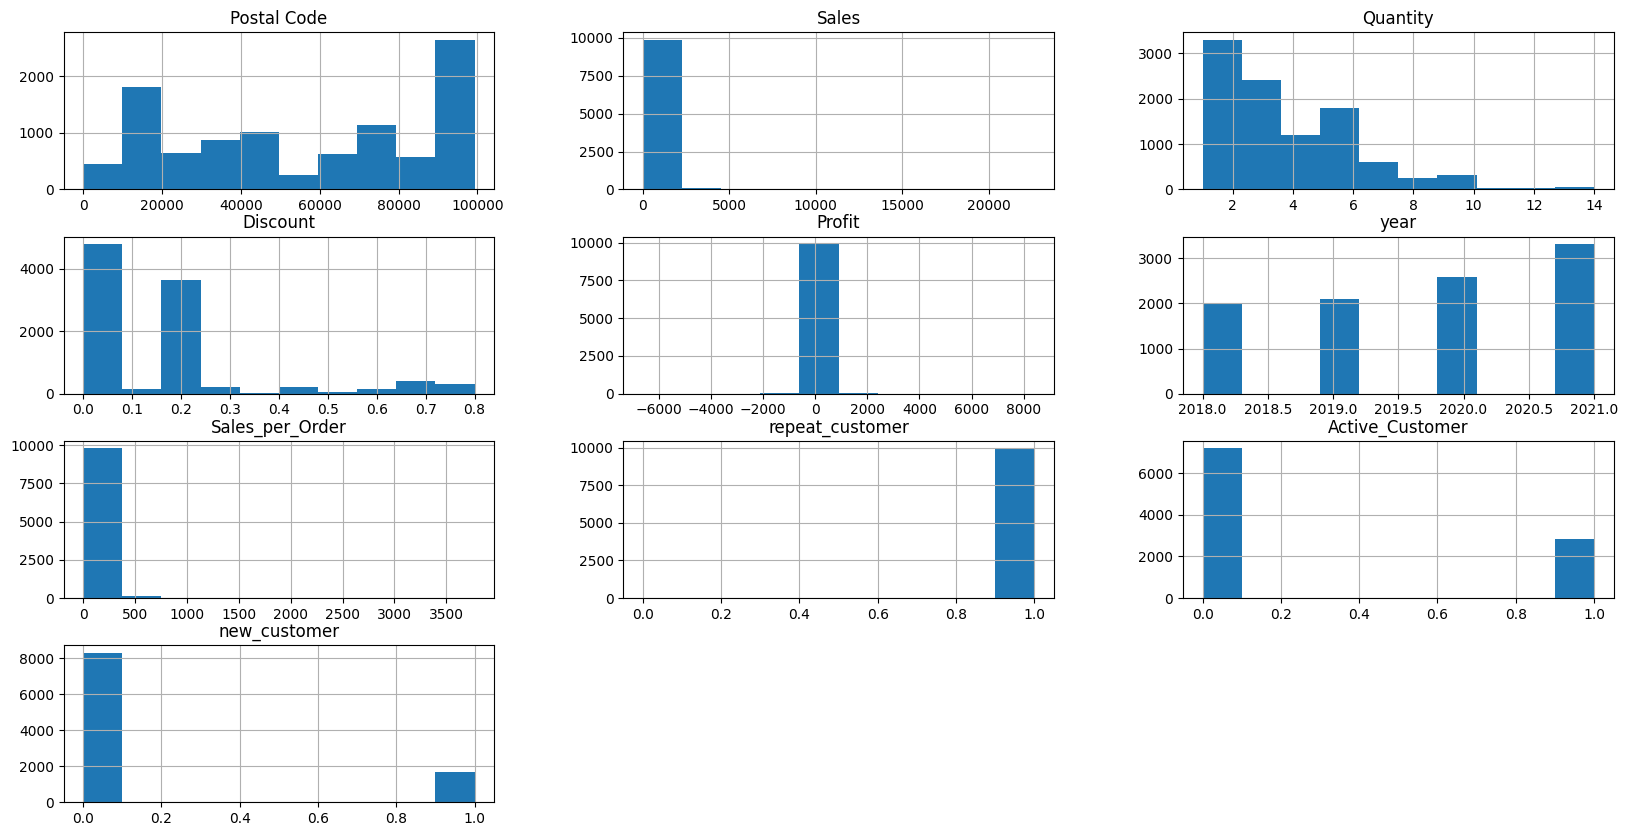

In [18]:
df.hist(figsize=(20, 10))

CountPlot To Check Data Unbalance

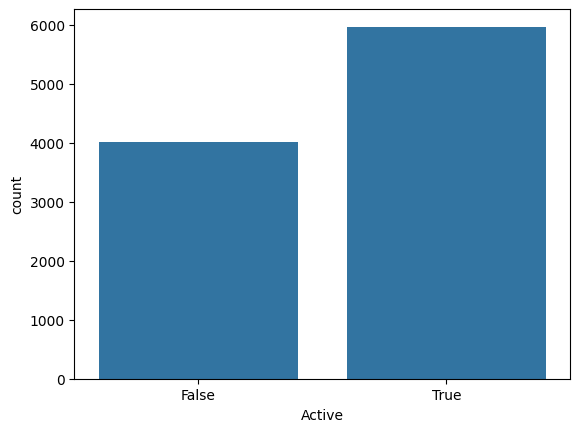

In [19]:
sns.countplot(x='Active', data=df)

plt.show()

Label Encoding for Columns With Few Unique Values

In [20]:
label_cols = ['Country/Region','Region', 'Category', 'year','Active','Segment']

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head(10)

,Segment,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Month,year,Sales_per_Order,repeat_customer,Active_Customer,Active,new_customer
0,0,0,Henderson,Kentucky,42420,2,0,Chairs,731.9400,3,0.00,219.5820,2020-11,2,243.9800,1,0,0,0
1,1,0,Los Angeles,California,90036,3,1,Labels,14.6200,2,0.00,6.8714,2020-06,2,7.3100,1,1,1,1
2,0,0,Fort Lauderdale,Florida,33311,2,0,Tables,957.5775,5,0.45,-383.0310,2019-10,1,191.5155,1,1,1,1
3,0,0,Fort Lauderdale,Florida,33311,2,1,Storage,22.3680,2,0.20,2.5164,2019-10,1,11.1840,1,1,1,1
4,0,0,Los Angeles,California,90032,3,0,Furnishings,48.8600,7,0.00,14.1694,2018-06,0,6.9800,1,1,1,1
5,0,0,Los Angeles,California,90032,3,1,Art,7.2800,4,0.00,1.9656,2018-06,0,1.8200,1,1,1,1
6,0,0,Los Angeles,California,90032,3,2,Phones,907.1520,6,0.20,90.7152,2018-06,0,151.1920,1,1,1,1
7,0,0,Los Angeles,California,90032,3,1,Binders,18.5040,3,0.20,5.7825,2018-06,0,6.1680,1,1,1,1
8,0,0,Los Angeles,California,90032,3,1,Appliances,114.9000,5,0.00,34.4700,2018-06,0,22.9800,1,1,1,1
9,0,0,Los Angeles,California,90032,3,0,Tables,1706.1840,9,0.20,85.3092,2018-06,0,189.5760,1,1,1,1


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Segment          9993 non-null   int64  
 1   Country/Region   9993 non-null   int64  
 2   City             9993 non-null   str    
 3   State            9993 non-null   str    
 4   Postal Code      9993 non-null   int64  
 5   Region           9993 non-null   int64  
 6   Category         9993 non-null   int64  
 7   Sub-Category     9993 non-null   str    
 8   Sales            9993 non-null   float64
 9   Quantity         9993 non-null   int64  
 10  Discount         9993 non-null   float64
 11  Profit           9993 non-null   float64
 12  Month            9993 non-null   str    
 13  year             9993 non-null   int64  
 14  Sales_per_Order  9993 non-null   float64
 15  repeat_customer  9993 non-null   int64  
 16  Active_Customer  9993 non-null   int64  
 17  Active           9993 non

Target Encoding For Columns With Many Unique Values

In [22]:
cols = ['City', 'State', 'Sub-Category', 'Month']

for col in cols:
    mean_values = df.groupby(col)['Active'].mean()
    df[col + '_enc'] = df[col].map(mean_values)

In [23]:
df.drop(['City','State','Sub-Category','Month'], axis=1, inplace=True)

In [24]:
df.head(15)

,Segment,Country/Region,Postal Code,Region,Category,Sales,Quantity,Discount,Profit,year,Sales_per_Order,repeat_customer,Active_Customer,Active,new_customer,City_enc,State_enc,Sub-Category_enc,Month_enc
0,0,0,42420,2,0,731.9400,3,0.00,219.5820,2,243.9800,1,0,0,0,0.620000,0.673913,0.596434,0.539295
1,1,0,90036,3,1,14.6200,2,0.00,6.8714,2,7.3100,1,1,1,1,0.601071,0.601699,0.563187,0.557789
2,0,0,33311,2,0,957.5775,5,0.45,-383.0310,1,191.5155,1,1,1,1,0.733333,0.616188,0.608150,0.481928
3,0,0,33311,2,1,22.3680,2,0.20,2.5164,1,11.1840,1,1,1,1,0.733333,0.616188,0.595745,0.481928
4,0,0,90032,3,0,48.8600,7,0.00,14.1694,0,6.9800,1,1,1,1,0.601071,0.601699,0.598746,0.451852
5,0,0,90032,3,1,7.2800,4,0.00,1.9656,0,1.8200,1,1,1,1,0.601071,0.601699,0.564070,0.451852
6,0,0,90032,3,2,907.1520,6,0.20,90.7152,0,151.1920,1,1,1,1,0.601071,0.601699,0.620922,0.451852
7,0,0,90032,3,1,18.5040,3,0.20,5.7825,0,6.1680,1,1,1,1,0.601071,0.601699,0.603414,0.451852
8,0,0,90032,3,1,114.9000,5,0.00,34.4700,0,22.9800,1,1,1,1,0.601071,0.601699,0.596567,0.451852
9,0,0,90032,3,0,1706.1840,9,0.20,85.3092,0,189.5760,1,1,1,1,0.601071,0.601699,0.608150,0.451852


Data Correlation

In [25]:
correlation = df.drop(['Active'], axis=1).corr()
correlation

,Segment,Country/Region,Postal Code,Region,Category,Sales,Quantity,Discount,Profit,year,Sales_per_Order,repeat_customer,Active_Customer,new_customer,City_enc,State_enc,Sub-Category_enc,Month_enc
Segment,1.000000,NaN,-0.010798,-0.005528,0.009990,0.010870,0.008061,-0.016745,0.013360,0.040826,0.011701,0.012121,-0.069271,-0.008929,0.013141,0.000018,0.014259,0.008884
Country/Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,-0.010798,NaN,1.000000,0.474743,-0.002427,-0.024018,0.012662,0.058538,-0.030089,0.004216,-0.024759,0.020592,0.012490,0.001059,-0.016055,-0.027738,0.007503,0.014109
Region,-0.005528,NaN,0.474743,1.000000,-0.005092,0.004214,0.013536,-0.212749,0.022214,-0.003373,0.005668,-0.000985,0.017081,-0.004635,-0.019981,-0.116722,-0.006951,0.014122
Category,0.009990,NaN,-0.002427,-0.005092,1.000000,0.040090,-0.003744,-0.063023,0.091525,0.005258,0.051630,0.009991,0.018297,-0.001224,-0.002661,-0.022713,0.368032,-0.010753
Sales,0.010870,NaN,-0.024018,0.004214,0.040090,1.000000,0.200805,-0.028187,0.479064,-0.009680,0.889384,0.003212,-0.017276,0.007712,-0.004119,-0.018404,-0.043644,0.001005
Quantity,0.008061,NaN,0.012662,0.013536,-0.003744,0.200805,1.000000,0.008563,0.066260,-0.005790,-0.003109,0.008078,-0.001242,0.001908,0.013926,-0.011784,0.005253,0.011938
Discount,-0.016745,NaN,0.058538,-0.212749,-0.063023,-0.028187,0.008563,1.000000,-0.219489,-0.002644,-0.032768,0.000167,-0.003760,0.000237,0.011317,0.092979,0.052971,0.003860
Profit,0.013360,NaN,-0.030089,0.022214,0.091525,0.479064,0.066260,-0.219489,1.000000,0.004669,0.468315,0.000052,-0.007795,-0.007553,-0.007687,-0.030492,-0.005256,-0.007270
year,0.040826,NaN,0.004216,-0.003373,0.005258,-0.009680,-0.005790,-0.002644,0.004669,1.000000,-0.002948,-0.035175,0.096355,-0.549134,0.065300,0.013743,0.003699,0.438450


<Axes: >

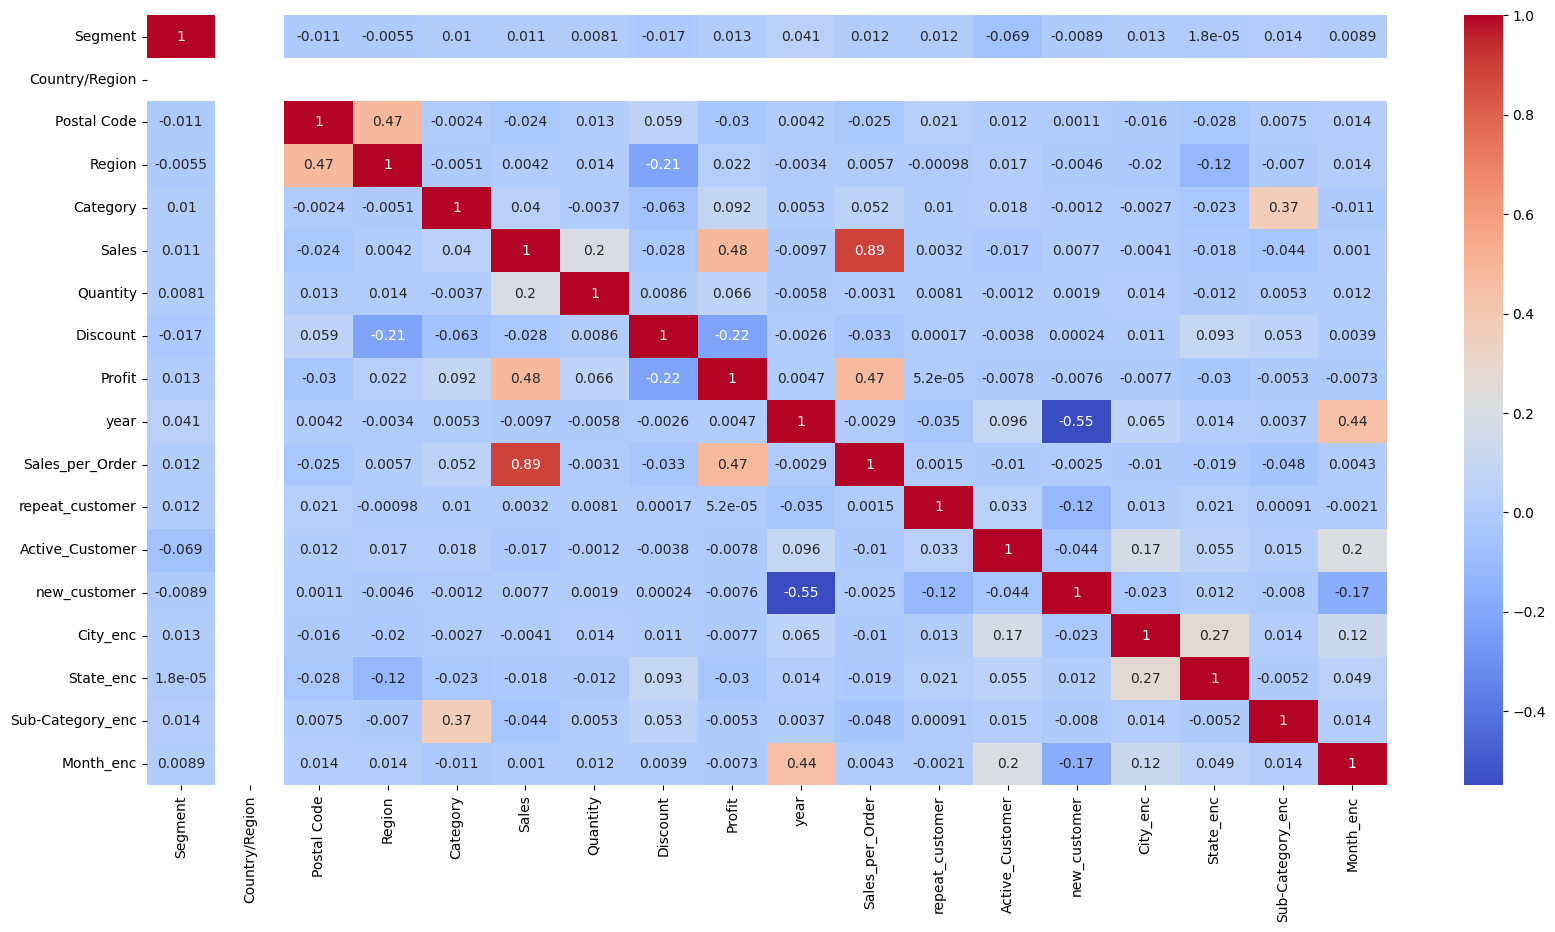

In [26]:
plt.figure(figsize=(20, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

Data Splitting [ Train , Test ]

In [27]:
X = df.drop('Active', axis = 1)
y = df['Active']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data Scaling

In [29]:
stand = StandardScaler()
x_train = stand.fit_transform(x_train)
x_test = stand.transform(x_test)

Model Selection

In [30]:
Model = LogisticRegression()
Model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Training

In [31]:
Model.score(x_test, y_test)
y_pred = Model.predict(x_test)
print(y_pred)

[0 1 0 ... 0 1 0]


Model Evaluation

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.768384192096048


In [33]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.8736637512147716


In [34]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.7297077922077922


In [35]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7952233524988943


Confusion Matrix

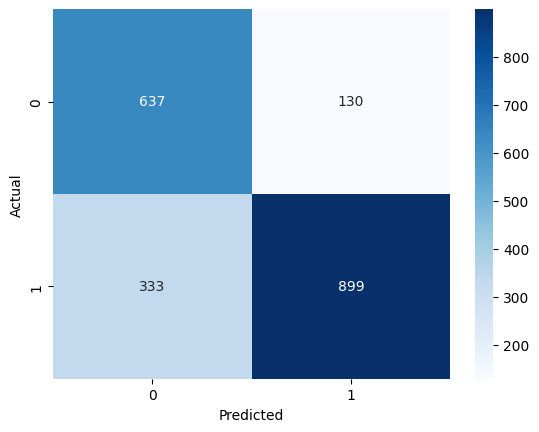

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()